In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely import Point, Polygon
from valhalla import Actor, get_config
from typing import Any, Callable
import contextily as cx
from shapely import from_wkt
import osmnx as ox
from matplotlib.font_manager import FontProperties

ox.settings.use_cache = True
ox.settings.log_console = False

In [2]:
fp = FontProperties(fname=r"../../data/fontawesome/Font Awesome 7 Free-Solid-900.otf")

In [3]:
def build_walk_query(
    location: dict[str, float], times: list[int] = [5, 10, 15]
) -> dict[str, Any]:
    return {
        "locations": [location],
        "costing": "pedestrian",
        "contours": [{"time": i} for i in times],
    }


def get_isochrone(query: dict, actor: Actor):
    result = {}
    isochrones = actor.isochrone(query)
    for contour_ix, isochrone in enumerate(isochrones["features"]):
        geom = isochrone["geometry"]["coordinates"]
        time = isochrone["properties"]["contour"]
        result[time] = Polygon(geom)
    return result


def determine_isochrones(
    points: gpd.GeoDataFrame,
    actor: Actor,
    times: list[int] = [5, 10, 15],
    costing: list[tuple[str, Callable]] = [
        ("walk", build_walk_query),
    ],
) -> pd.DataFrame:
    isochrone = []
    for row in points.itertuples():
        for label, func in costing:
            r = get_isochrone(
                func({"lon": row.lon, "lat": row.lat}, times=times),
                actor,
            )
            for t in times:
                if t in r:
                    isochrone.append([row.h3, r[t], label, t])
                else:
                    isochrone.append([row.h3, None, label, t])
    return pd.DataFrame.from_records(
        isochrone, columns=["h3", "geometry", "costing", "range"]
    )

In [4]:
CITY = "budapest"

In [5]:
config = get_config(tile_extract=f"../../data/valhalla/{CITY}/valhalla_tiles.tar")
config["service_limits"]["pedestrian"]["max_matrix_location_pairs"] = 1_000_000

actor = Actor(config)

In [6]:
points = gpd.GeoDataFrame(geometry=[Point(19.11501710545673, 47.46386261520024)], crs=4326)
points["lon"] = points.geometry.x
points["lat"] = points.geometry.y

In [7]:
polygon = get_isochrone(
    build_walk_query(location={"lon": 19.11501710545673, "lat": 47.46386261520024}, times=[15]),
    actor,
)[15]

area = gpd.GeoDataFrame(geometry=[polygon], crs=4326)


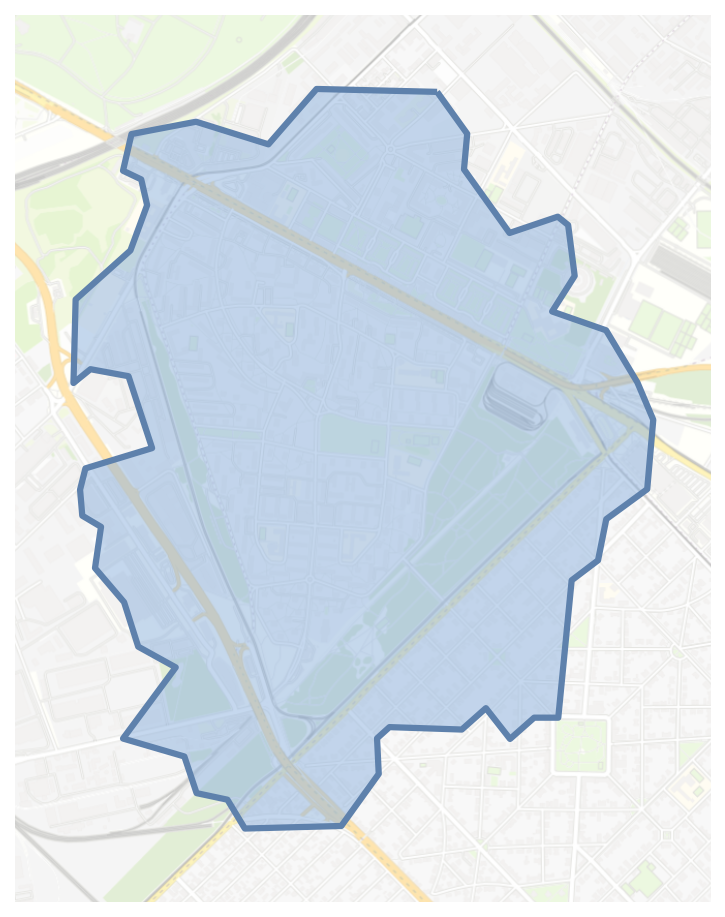

In [9]:
fig, ax = plt.subplots(figsize=(5, 6), dpi=150, layout="constrained")
ax.margins(0.1)
area.to_crs(23700).plot(ax=ax, ec="#5E81AC", fc="#8cb1de7f", lw=3)
cx.add_basemap(
        ax,
        crs=23700,
        source=cx.providers.OpenStreetMap.BZH,
        alpha=0.5,
        attribution=False,
    )
_ = ax.axis("off")

In [10]:
tags = {'amenity': [
            "restaurant", "fast_food", "cafe", "ice_cream", 'pub',
            "school",
            "kindergarten",
            "preschool",
            "pharmacy",
            "chemist",
            "doctors",
            "hospital",
            "place_of_worship",
            "arts_centre",
            "theatre",
            "cinema",
            "post_office",
            "bank"
        ],
        "shop": [
                "supermarket",
                "grocery",
                "convenience",
                "hairdresser",
                "beauty",
                "laundry",
                "dry_cleaning"
        ],
        'tourism': ['museum', "gallery"],
        "leisure": ["playground", "park", "tanning_salon"]
}
gdf = ox.features.features_from_polygon(polygon, tags=tags)

In [11]:
amenities = gdf[gdf["geometry"].geom_type=="Point"].copy()

In [12]:
am = pd.read_csv("../../output/budapest/amenities/amenities_filtered.wkt.csv")
am["geometry"] = am["geometry"].apply(from_wkt)
am = gpd.GeoDataFrame(am, crs=4326)
# am = am[(am["geometry"].geom_type == "Point") & (am["geometry"].within(polygon))].copy()
am = am[(am["geometry"].within(polygon))].copy()
am = am.to_crs(23700)

In [13]:
am["geometry"] = am.to_crs(23700)["geometry"].centroid

In [14]:
icons = {
    "amenity:preschool": "\uf549",
    "amenity:kindergarten": "\uf549",
    "amenity:school": "\uf549",
    "amenity:post_office": "\uf0e0",
    "amenity:restaurant": "\uf2e7",
    "amenity:fast_food": "\uf2e7",
    "shop:supermarket": "\uf07a",
    "shop:grocery": "\uf07a",
    "shop:convenience": "\uf07a",
    "amenity:pharmacy": "\uf486",
    "amenity:hospital": "\ue3b2",
    "amenity:doctors": "\ue3b2",
    "amenity:place_of_worship": "\uf51d",
    "amenity:police": "\ue4d8",
}

In [20]:
am[am["category"].isin(icons.keys())].to_file("debug.geojson")

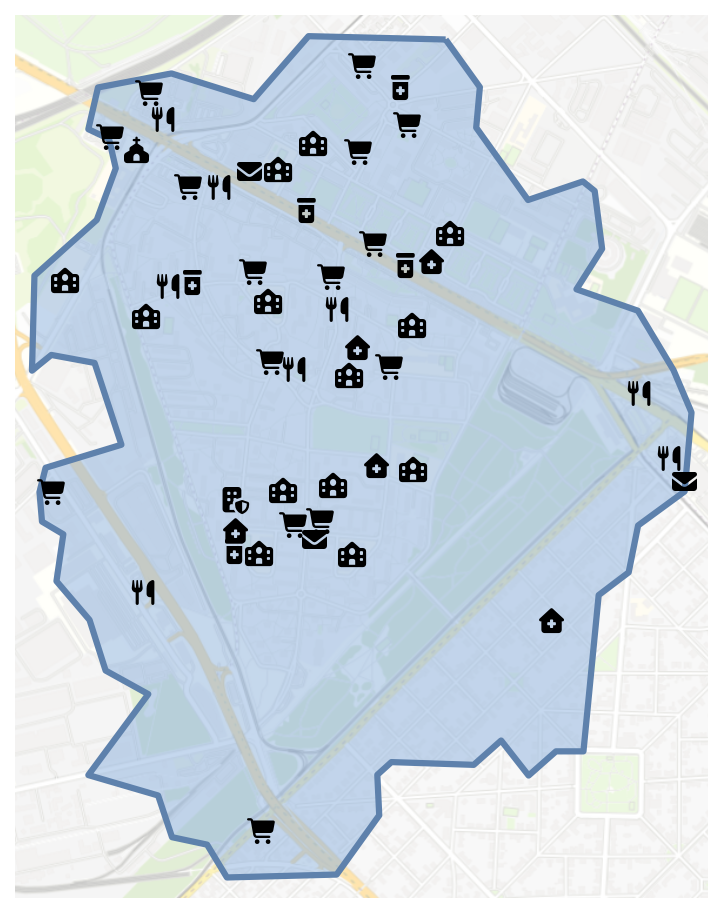

In [ ]:
drop_to_prevent_overlap = [3478495199, 6016462131, 6050952542, 3478529396, 12463630247, 340336709, 340147454, 3478524065, 3478539498, 3478506033]
reposition_to_prevent_overlap = {
    3478484949: {"va": "top", "ha": "center"},
    3478486175: {"va": "top", "ha": "center"},
    3478525182: {"va": "bottom", "ha": "center"},
    340147453: {"va": "center", "ha": "right"},
    12132322373: {"va": "bottom", "ha": "center"},
    300423583: {"va": "center", "ha": "left"},
    5440081550: {"va": "bottom", "ha": "center"},
    3045211748: {"va": "bottom", "ha": "center"},
}

fig, ax = plt.subplots(figsize=(4.7, 6), dpi=150, layout="constrained")
ax.margins(0.025)
area.to_crs(23700).plot(ax=ax, ec="#5E81AC", fc="#8cb1de7f", lw=3)
cx.add_basemap(
        ax,
        crs=23700,
        source=cx.providers.OpenStreetMap.BZH,
        alpha=0.5,
        attribution=False,
    )
_ = ax.axis("off")

for cat, icon in icons.items():
    for row in am[(am["category"]==cat) & (~am["osm_id"].isin(drop_to_prevent_overlap))].itertuples():
        va = "center"
        ha = "center"
        if row.osm_id in reposition_to_prevent_overlap:
            va = reposition_to_prevent_overlap[row.osm_id]["va"]
            ha = reposition_to_prevent_overlap[row.osm_id]["ha"]
        ax.text(row.geometry.x, row.geometry.y, icon, fontproperties=fp, fontsize="12", va=va, ha=ha)

fig.savefig("../../output/budapest/amenities_in_jozsefattila.png", pad_inches=0)